# Progetto di analisi del testo

## Domande di ricerca
- Parole ricercate - linguaggio alto/basso (misurata per regione, istruzione,
età…)
- Ripetizioni / varietà lessicali
- Quali cose importanti
- Errori di scrittura (di tipo sintattico, ortografico)
- Specificità (regionalismi, parole straniere, parole che spiccano come specifiche (molto usate rispetto agli altri profili))
- Paratassi/ ipotassi - complessità sintattica (lunghezza delle frasi) (part of speech - tempi verbali, aggettivi, avverbi)
- Rispetto dei vincoli (coerenza tra testo e profilo)

In [5]:
import pymongo
import pandas as pd 
import numpy as np 
from collections import defaultdict
import matplotlib.pyplot as plt
import spacy 
from nltk.tokenize import word_tokenize, sent_tokenize

ImportError: cannot import name 'Sentinel' from 'typing_extensions' (/Users/Flint/.pyenv/versions/gensim/lib/python3.10/site-packages/typing_extensions.py)

In [4]:
nlp = spacy.load('it_core_news_lg')

In [5]:
db = pymongo.MongoClient()['gentext']['ita']

In [6]:
sample = list(db.find().limit(20))

In [8]:
for k, v in sample[0].items():
    print(f"{k} ==> {v}")

_id ==> 691f5a2952ecf561516990d2
model ==> gpt-4o-mini
doc_id ==> 6898_0
profile_id ==> 6898
age_class ==> 51-71
text ==> Nella vita, le cose importanti sono spesso le più semplici. La famiglia, gli amici e le esperienze condivise ci arricchiscono. La salute è fondamentale, perché senza di essa, tutto il resto perde valore. Coltivare passioni e interessi ci permette di affrontare le sfide con entusiasmo. Infine, è essenziale trovare un senso di pace interiore, che ci aiuti ad apprezzare ogni giorno.
instruction ==> Scrivi un breve testo sulle cose importanti della vita
profession ==> disoccupato
age ==> 63
level of education ==> superiore
gender ==> femmina
region ==> Piemonte


## Tokenizzazione

In [9]:
def tokenize(text):
    return word_tokenize(text.lower(), language='italian')

In [32]:
def indexing(query=None):
    if query is None:
        query = {}
    word_count = 0
    word_index = defaultdict(lambda: defaultdict(lambda: 0))
    for doc in db.find(query):
        doc_id = f"{doc['doc_id']}_{doc['model']}"
        text = doc['text']
        tokens = tokenize(text)
        for token in tokens:
            word_count += 1
            word_index[doc_id][token] += 1
    I = pd.DataFrame(word_index).fillna(0).T
    return I, word_count

In [33]:
I, word_count = indexing()

In [34]:
I.head()

,nella,vita,",",le,cose,importanti,sono,spesso,più,semplici,...,operazione,princìpi,consapev,ritenerlo,interamente,psicofisica,avviato,specifiche,rendeva,iniziati
6898_0_gpt-4o-mini,1.0,1.0,6.0,4.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6898_1_gpt-4o-mini,1.0,2.0,7.0,1.0,1.0,0.0,2.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5998_0_gpt-4o-mini,1.0,1.0,3.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5998_1_gpt-4o-mini,1.0,1.0,7.0,1.0,1.0,0.0,2.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1218_0_gpt-4o-mini,1.0,2.0,5.0,2.0,0.0,0.0,3.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


**Frequenza relativa**

In [37]:
def relfreq(word, idx, word_count):
    try:
        return np.log(idx[word].sum() / word_count)
    except KeyError:
        return 0

In [38]:
test_words = ['vita', 'famiglia', 'il', 'buono']
for word in test_words:
    print(f"{word} => {np.round(relfreq(word, I, word_count), 6)}")

vita => -4.244641
famiglia => -4.947526
il => -4.09335
buono => -10.612221


### Specificità

In [63]:
query = {'gender': 'femmina'}
fem_idx, fem_count = indexing(query=query)

In [64]:
general = relfreq('vita', I, word_count)
fem = relfreq('vita', fem_idx, fem_count)
print(f"Corpus: {general}")
print(f"Femminile: {fem}")
print(fem - general)

Corpus: -4.244641455788669
Femminile: -4.253030723709168
-0.008389267920499321


In [65]:
def select_terms(idx, size=100):
    tf = idx.sum(axis=0)
    df = (idx > 0).sum(axis=0)
    idf = np.log(idx.shape[0] / df)
    tfidf = tf * idf 
    words = tfidf.sort_values(ascending=False).head(size).index.values
    return list(words)

In [66]:
terms = select_terms(fem_idx, size=100)
print(terms)

['ci', 'ho', 'mia', 'una', 'a', 'mi', 'della', 'mio', 'un', 'ma', 'i', '’', 'il', 'in', 'più', 'le', 'l', 'non', 'con', 'ciò', 'gli', 'lavoro', 'ogni', 'perché', 'del', 'nei', 'anche', 'tutto', 'per', 'giorno', 'importante', ':', 'davvero', 'momenti', 'amici', 'salute', 'fondamentale', 'difficili', 'relazioni', 'come', 'da', 'contano', 'passione', 'anni', 'nostro', 'senza', 'importanti', 'amore', 'altri', 'vivere', 'infine', 'si', 'sempre', 'alla', 'cose', 'imparato', 'famiglia', 'persone', 'nel', 'cura', 'terra', 'ha', 'me', 'senso', 'piccole', 'prezioso', 'essa', 'coltivare', 'rende', 'miei', 'valore', 'sia', 'rispetto', 'gratitudine', 'al', 'gioie', 'quotidiane', 'danno', 'stessi', 'fondamentali', 'sostengono', "l'amore", 'cuore', 'passioni', 'sostiene', 'dà', 'nella', 'mai', 'tempo', 'gioia', 'essere', 'arricchiscono', 'solo', 'godere', 'donna', 'dono', 'poi', 'imparare', 'o', 'di']


In [67]:
def specificity(query, size=100):
    vocab = {}
    idx, wc = indexing(query=query)
    terms_to_probe = select_terms(idx, size=size)
    for term in terms_to_probe:
        corpus_freq = relfreq(term, I, word_count)
        query_freq = relfreq(term, idx, wc)
        vocab[term] = query_freq - corpus_freq
    return pd.Series(vocab).sort_values(ascending=False)    

In [71]:
fem = {'gender': 'femmina'}
mas = {'gender': 'maschio'}

puglia = {'region': 'Puglia'}

In [70]:
fem_spec = specificity(fem, size=100)
print(fem_spec.head(20))

donna          0.686795
una            0.286605
dono           0.182598
l'amore        0.146966
amore          0.145143
stessi         0.138311
prezioso       0.135844
cuore          0.128283
cura           0.123437
l              0.111907
’              0.109353
gratitudine    0.106650
coltivare      0.090057
quotidiane     0.086261
piccole        0.078705
sostiene       0.076907
anche          0.074744
gioie          0.071751
del            0.070240
gioia          0.069290
dtype: float64


In [72]:
mas_spec = specificity(mas, size=100)
print(mas_spec.head(20))

resto        0.151452
un           0.143376
;            0.141119
senza        0.141056
umane        0.138995
essa         0.136328
tutto        0.133078
sostegno     0.130426
poi          0.113391
avere        0.095316
senso        0.084219
al           0.079260
nostre       0.069938
valore       0.068638
godere       0.066179
:            0.061039
lavoro       0.061028
difficile    0.057009
solo         0.055034
facciamo     0.052139
dtype: float64


In [73]:
p_spec = specificity(puglia, size=100)
print(p_spec.head(20))

puglia        2.929902
pugliese      2.929902
terra         0.273579
contano       0.165591
sostiene      0.164130
:             0.163906
;             0.160034
rispetto      0.148156
amore         0.140204
come          0.129369
alla          0.127754
l'amore       0.126717
quotidiane    0.117742
poi           0.117107
mia           0.112484
cuore         0.111877
anni          0.096335
valori        0.093657
i             0.080525
rende         0.077678
dtype: float64


In [75]:
lom_spec = specificity({'region': 'Lombardia'}, size=100)
print(lom_spec.head(5))

lombardia        2.971477
affrontare       0.250266
umane            0.218684
arricchiscono    0.168993
senso            0.159426
dtype: float64


In [77]:
gpt_spec = specificity({'model': 'gpt-4o-mini'}, size=100)
print(gpt_spec.head(20))

arricchiscono    0.520406
arricchisce      0.519913
’                0.519468
perde            0.519255
davvero          0.517439
l                0.516777
resto            0.515881
sostengono       0.514346
sostiene         0.513549
gratitudine      0.511824
gioie            0.510992
contano          0.509969
facciamo         0.502043
amicizia         0.499805
quotidiane       0.496049
umane            0.492834
poi              0.492656
essa             0.491769
passioni         0.487833
legami           0.485233
dtype: float64


In [78]:
mistral_spec = specificity({'model': 'mistralai/Mistral-7B-Instruct-v0.3'}, size=100)
print(mistral_spec.head(20))

insegnante     0.901576
superiore      0.901576
regione        0.901576
studiato       0.901576
secondaria     0.901576
sì             0.901576
primaria       0.901576
donna          0.901576
laurea         0.900700
giovane        0.900445
avuto          0.899262
paese          0.897774
stata          0.897372
miei           0.895052
mie            0.893492
mia            0.891185
ed             0.891074
scuola         0.889608
dalla          0.881942
professione    0.869195
dtype: float64


## Varietà lessicale

In [86]:
def type_ratio(row):
    word_type = (row > 0).sum() / row.sum()
    return word_type

In [87]:
idx_p, wc_p = indexing(query={'level of education': 'primaria'})
idx_l, wc_l = indexing(query={'level of education': 'laurea'})

In [88]:
t_ratio_p = []
for i, row in idx_p.iterrows():
    t_ratio_p.append(type_ratio(row))
t_ratio_l = []
for i, row in idx_l.iterrows():
    t_ratio_l.append(type_ratio(row))

In [92]:
import seaborn as sns

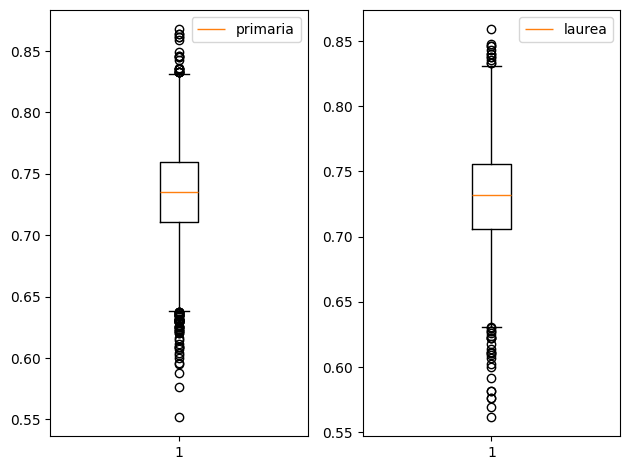

In [96]:
fig, ax = plt.subplots(ncols=2)
ax[0].boxplot(t_ratio_p, label='primaria')
ax[0].legend()
ax[1].boxplot(t_ratio_l, label='laurea')
ax[1].legend()
plt.tight_layout()
plt.show()
